# Detección y Clasificación de Figuras Geométricas
Detectar figuras, calcular momentos de Hu y clasificarlas por forma

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# Cargar imagen
img = cv2.imread('colores.jpg')

In [10]:
def clasificar_figura(contorno):
    momentos = cv2.moments(contorno)
    momentos_hu = cv2.HuMoments(contorno)
    
    epsilon = 0.02 * cv2.arcLength(contorno, True)
    aprox = cv2.approxPolyDP(contorno, epsilon, True)
    num_vertices = len(aprox)
    
    area = cv2.contourArea(contorno)
    perimetro = cv2.arcLength(contorno, True)
    circularidad = (4 * np.pi * area) / (perimetro ** 2)
    
    if circularidad > 0.7:
        tipo = "Círculo"
    elif num_vertices == 3:
        tipo = "Triángulo"
    elif num_vertices == 4:
        x, y, w, h = cv2.boundingRect(aprox)
        aspecto = float(w) / h if h > 0 else 0
        tipo = "Cuadrado" if 0.8 < aspecto < 1.2 else "Rectángulo"
    elif num_vertices == 5:
        tipo = "Pentágono"
    else:
        tipo = f"Polígono ({num_vertices} lados)"
    
    return tipo, num_vertices, momentos_hu, circularidad

In [11]:
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binaria = cv2.threshold(gris, 127, 255, cv2.THRESH_BINARY_INV)
contornos, _ = cv2.findContours(binaria, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

resultados = []
for contorno in contornos:
    if cv2.contourArea(contorno) > 100:
        tipo, vertices, hu_moments, circularidad = clasificar_figura(contorno)
        resultados.append({
            'tipo': tipo,
            'vertices': vertices,
            'circularidad': circularidad,
            'hu_moments': hu_moments,
            'contorno': contorno
        })

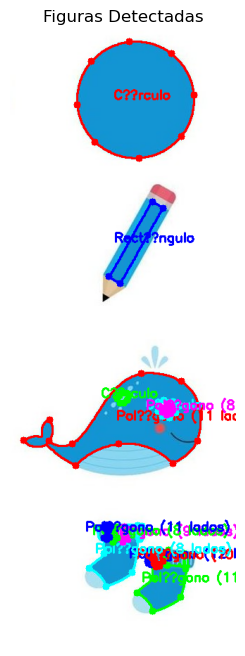

In [12]:
img_resultado = img.copy()
colores = [(0, 255, 0), (255, 0, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]

for i, resultado in enumerate(resultados):
    color = colores[i % len(colores)]
    contorno = resultado['contorno']
    
    cv2.drawContours(img_resultado, [contorno], 0, color, 2)
    
    epsilon = 0.02 * cv2.arcLength(contorno, True)
    aprox = cv2.approxPolyDP(contorno, epsilon, True)
    for punto in aprox:
        cv2.circle(img_resultado, tuple(punto[0]), 5, color, -1)
    
    momentos = cv2.moments(contorno)
    cx = int(momentos['m10'] / momentos['m00'])
    cy = int(momentos['m01'] / momentos['m00'])
    cv2.putText(img_resultado, resultado['tipo'], (cx - 30, cy), 
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB))
plt.title("Figuras Detectadas")
plt.axis('off')
plt.show()

In [13]:
for i, resultado in enumerate(resultados):
    print(f"\nFigura {i + 1}: {resultado['tipo']}")
    print(f"  Vértices: {resultado['vertices']}")
    print(f"  Circularidad: {resultado['circularidad']:.3f}")
    print(f"  Momentos de Hu: {resultado['hu_moments'].flatten()}")


Figura 1: Polígono (11 lados)
  Vértices: 11
  Circularidad: 0.226
  Momentos de Hu: [0. 0. 0. 0. 0. 0. 0.]

Figura 2: Polígono (12 lados)
  Vértices: 12
  Circularidad: 0.306
  Momentos de Hu: [0. 0. 0. 0. 0. 0. 0.]

Figura 3: Polígono (10 lados)
  Vértices: 10
  Circularidad: 0.377
  Momentos de Hu: [0. 0. 0. 0. 0. 0. 0.]

Figura 4: Polígono (8 lados)
  Vértices: 8
  Circularidad: 0.319
  Momentos de Hu: [0. 0. 0. 0. 0. 0. 0.]

Figura 5: Polígono (9 lados)
  Vértices: 9
  Circularidad: 0.375
  Momentos de Hu: [0. 0. 0. 0. 0. 0. 0.]

Figura 6: Polígono (8 lados)
  Vértices: 8
  Circularidad: 0.231
  Momentos de Hu: [0. 0. 0. 0. 0. 0. 0.]

Figura 7: Polígono (11 lados)
  Vértices: 11
  Circularidad: 0.184
  Momentos de Hu: [0. 0. 0. 0. 0. 0. 0.]

Figura 8: Polígono (11 lados)
  Vértices: 11
  Circularidad: 0.359
  Momentos de Hu: [0. 0. 0. 0. 0. 0. 0.]

Figura 9: Círculo
  Vértices: 8
  Circularidad: 0.910
  Momentos de Hu: [0. 0. 0. 0. 0. 0. 0.]

Figura 10: Polígono (8 lados)
  Vérti